# 02 - Patrones de vulnerabilidades

Análisis de vulnerabilidades Grype consolidadas en `analysis.json`: severidad, artefactos más afectados, CWE, disponibilidad de fix y segmentación por tipo/lenguaje.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'results' / 'analysis.json').exists():
            return candidate
    return Path.cwd()


analysis_path = find_project_root() / 'data' / 'results' / 'analysis.json'
with analysis_path.open('r', encoding='utf-8') as f:
    analysis = json.load(f)

vuln_rows = []
for repo in analysis.get('repositories', []):
    for item in repo.get('vulnerabilities', {}).get('items', []) or []:
        vuln_rows.append({
            'repo': repo.get('name', 'unknown'),
            'id': item.get('id'),
            'severity': item.get('severity', 'Unknown'),
            'artifact': item.get('artifact', 'unknown'),
            'artifact_type': item.get('artifact_type', 'unknown'),
            'artifact_language': item.get('artifact_language', 'unknown') or 'unknown',
            'cwe': item.get('cwe', 'Unknown') or 'Unknown',
            'fix_available': bool(item.get('fix_available', False)),
        })

df_vulns = pd.DataFrame(vuln_rows)
if df_vulns.empty:
    df_vulns = pd.DataFrame(columns=['repo','id','severity','artifact','artifact_type','artifact_language','cwe','fix_available'])

df_vulns.head()


,repo,id,severity,artifact,artifact_type,artifact_language,cwe,fix_available
0,deepagents,GHSA-jm6w-m3j8-898g,High,nltk,python,python,CWE-306,True
1,deepagents,GHSA-gfwx-w7gr-fvh7,Medium,nltk,python,python,CWE-79,True
2,deepagents,GHSA-5239-wwwm-4pmq,Low,pygments,python,python,CWE-400,True
3,deepagents,GHSA-r75f-5x8p-qvmc,Critical,litellm,python,python,Unknown,True
4,deepagents,GHSA-v4p8-mg3p-g94g,High,litellm,python,python,Unknown,True


In [2]:
severity_order = ['Critical', 'High', 'Medium', 'Low', 'Unknown']
severity_counts = df_vulns['severity'].value_counts().reindex(severity_order, fill_value=0)
top_artifacts = df_vulns['artifact'].value_counts().head(10)
top_cwe = df_vulns['cwe'].value_counts().head(10)
fix_counts = df_vulns['fix_available'].map({True: 'Fix disponible', False: 'Sin fix'}).value_counts()
by_type = df_vulns['artifact_type'].value_counts().head(10)
by_language = df_vulns['artifact_language'].value_counts().head(10)

display(severity_counts.to_frame('count'))
display(top_artifacts.to_frame('count'))
display(top_cwe.to_frame('count'))
display(fix_counts.to_frame('count'))


,count
severity,
Critical,1
High,5
Medium,12
Low,4
Unknown,0


,count
artifact,
uuid,8
nltk,3
litellm,3
pygments,2
pypa/gh-action-pypi-publish,2
gradle/gradle-build-action,2
fast-xml-parser,1
@anthropic-ai/sdk,1


,count
cwe,
Unknown,16
CWE-400,2
CWE-200,2
CWE-306,1
CWE-79,1


,count
fix_available,
Fix disponible,21
Sin fix,1


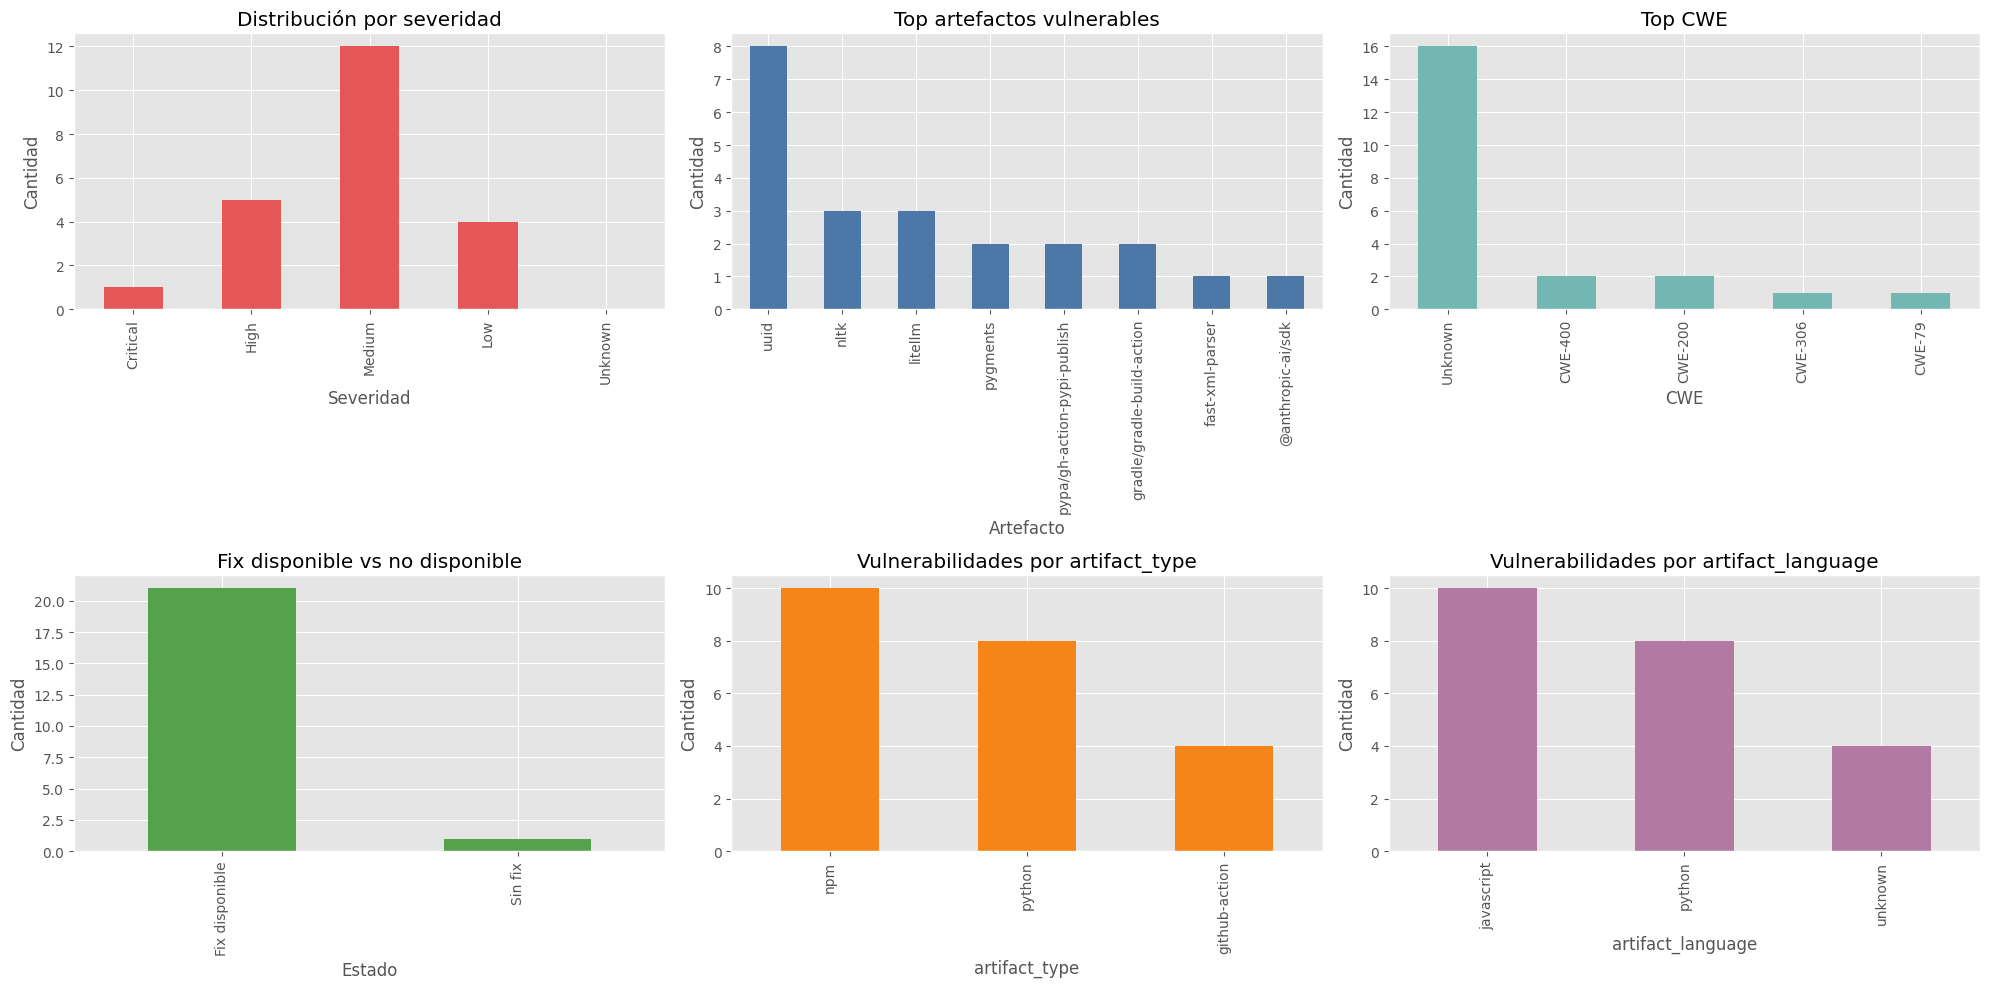

In [3]:
plt.style.use('ggplot')
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

severity_counts.plot(kind='bar', ax=axes[0, 0], color='#E45756', title='Distribución por severidad')
axes[0, 0].set_xlabel('Severidad')
axes[0, 0].set_ylabel('Cantidad')

top_artifacts.plot(kind='bar', ax=axes[0, 1], color='#4C78A8', title='Top artefactos vulnerables')
axes[0, 1].set_xlabel('Artefacto')
axes[0, 1].set_ylabel('Cantidad')

top_cwe.plot(kind='bar', ax=axes[0, 2], color='#72B7B2', title='Top CWE')
axes[0, 2].set_xlabel('CWE')
axes[0, 2].set_ylabel('Cantidad')

fix_counts.plot(kind='bar', ax=axes[1, 0], color='#54A24B', title='Fix disponible vs no disponible')
axes[1, 0].set_xlabel('Estado')
axes[1, 0].set_ylabel('Cantidad')

by_type.plot(kind='bar', ax=axes[1, 1], color='#F58518', title='Vulnerabilidades por artifact_type')
axes[1, 1].set_xlabel('artifact_type')
axes[1, 1].set_ylabel('Cantidad')

by_language.plot(kind='bar', ax=axes[1, 2], color='#B279A2', title='Vulnerabilidades por artifact_language')
axes[1, 2].set_xlabel('artifact_language')
axes[1, 2].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()


## Interpretación de patrones

- La distribución por severidad permite enfocar remediación urgente en High/Critical.
- El top de artefactos y CWE ayuda a detectar dependencias o clases de fallo repetitivas.
- La métrica de fix disponible permite separar backlog accionable inmediato de deuda técnica sin parche.
- La segmentación por `artifact_type`/`artifact_language` orienta ownership técnico por stack.

In [4]:
repo_metrics = []
for repo in analysis.get('repositories', []):
    repo_metrics.append({
        'name': repo.get('name', 'unknown'),
        'risk_score': float(repo.get('metrics', {}).get('risk_score', 0.0) or 0.0),
        'cicd_findings': int(repo.get('cicd', {}).get('total_findings', 0) or 0),
    })

df_repo_metrics = pd.DataFrame(repo_metrics)
top_repo = 'N/A'
top_risk = 0.0
if not df_repo_metrics.empty:
    df_repo_metrics = df_repo_metrics.sort_values('risk_score', ascending=False).reset_index(drop=True)
    top_repo = str(df_repo_metrics.iloc[0].get('name', 'N/A'))
    top_risk = float(df_repo_metrics.iloc[0].get('risk_score', 0.0) or 0.0)

severity_counts_dyn = df_vulns['severity'].value_counts() if not df_vulns.empty else pd.Series(dtype='int64')
most_common_severity = str(severity_counts_dyn.idxmax()) if not severity_counts_dyn.empty else 'Unknown'
total_high_critical = int(severity_counts_dyn.get('High', 0) + severity_counts_dyn.get('Critical', 0))
total_cicd = int(df_repo_metrics['cicd_findings'].sum()) if not df_repo_metrics.empty else 0

print('Conclusiones dinámicas (patrones):')
print(f'- Repo con mayor risk_score: {top_repo} ({top_risk:.2f})')
print(f'- Severidad más común: {most_common_severity}')
print(f'- Total High/Critical: {total_high_critical}')
print(f'- Total hallazgos CI/CD: {total_cicd}')


Conclusiones dinámicas (patrones):
- Repo con mayor risk_score: deepagents (2.31)
- Severidad más común: Medium
- Total High/Critical: 6
- Total hallazgos CI/CD: 4
